<a href="https://colab.research.google.com/github/razankablan/razankablan-data-analysis-exercises/blob/main/Chapter_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
%matplotlib inline


In [3]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving earthquakes.csv to earthquakes.csv


In [4]:
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

User uploaded file "earthquakes.csv" with length 589457 bytes


In [5]:
uploaded

{'earthquakes.csv': b'mag,magType,time,place,tsunami,parsed_place\n1.35,ml,1539475168010,"9km NE of Aguanga, CA",0,California\n1.29,ml,1539475129610,"9km NE of Aguanga, CA",0,California\n3.42,ml,1539475062610,"8km NE of Aguanga, CA",0,California\n0.44,ml,1539474978070,"9km NE of Aguanga, CA",0,California\n2.16,md,1539474716050,"10km NW of Avenal, CA",0,California\n2.61,md,1539473686440,"55km ESE of Punta Cana, Dominican Republic",0,Dominican Republic\n1.7,ml,1539473176017,"105km W of Talkeetna, Alaska",0,Alaska\n1.13,md,1539473060280,"10km NW of Parkfield, CA",0,California\n0.92,md,1539473042310,"6km NW of The Geysers, CA",0,California\n4.7,mb,1539472814760,"219km SSE of Saparua, Indonesia",0,Indonesia\n0.5,ml,1539471831030,"10km NE of Aguanga, CA",0,California\n2.77,md,1539471621260,"53km SE of Punta Cana, Dominican Republic",0,Dominican Republic\n0.5,ml,1539470934710,"9km NE of Aguanga, CA",0,California\n4.5,mb,1539470898340,"120km SSW of Banda Aceh, Indonesia",0,Indonesia\n2.13,md,1

In [8]:
import pandas as pd
earthquakes = pd.read_csv("earthquakes.csv")

In [12]:
df = pd.read_csv('/content/earthquakes.csv')

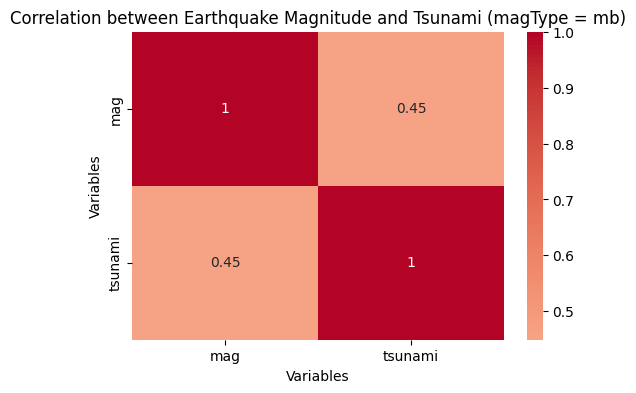

In [13]:
# Filter for magType == 'mb'
df_mb = df[df['magType'] == 'mb']

# Select only relevant numeric columns
data = df_mb[['mag', 'tsunami']]

# Compute correlation matrix
corr = data.corr()

# Create a seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

# Add titles and labels
plt.title('Correlation between Earthquake Magnitude and Tsunami (magType = mb)')
plt.xlabel('Variables')
plt.ylabel('Variables')

# Show plot
plt.show()

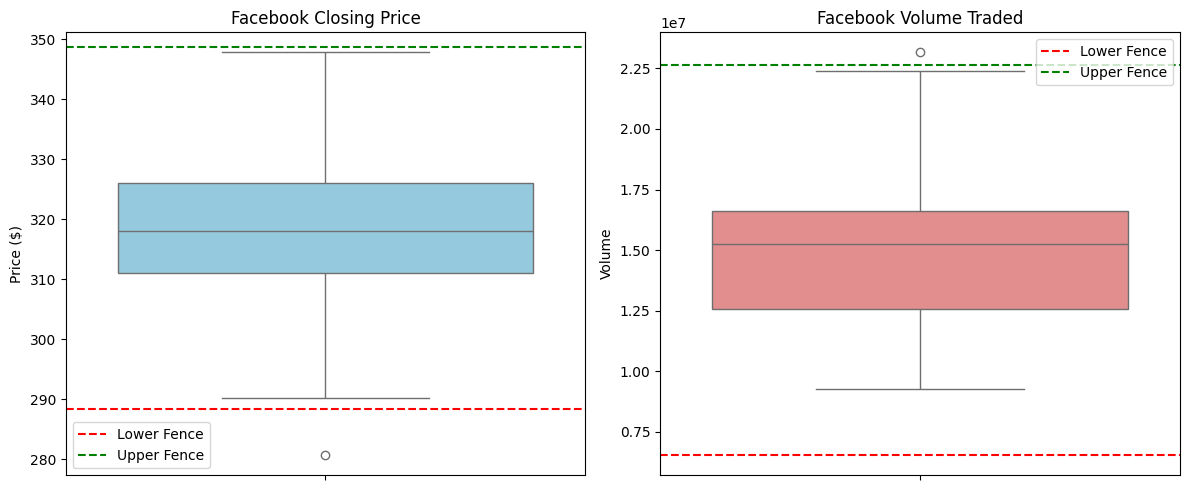

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Load your Facebook stock data
# Replace this with your actual file name
# df = pd.read_csv('facebook.csv')

# For demonstration, let's create a sample DataFrame
import numpy as np
np.random.seed(42)
df = pd.DataFrame({
    'Close': np.random.normal(320, 15, 100),   # simulated closing prices
    'Volume': np.random.normal(1.5e7, 3e6, 100)  # simulated trading volume
})

# Compute quartiles and IQR for Close
Q1_close = df['Close'].quantile(0.25)
Q3_close = df['Close'].quantile(0.75)
IQR_close = Q3_close - Q1_close
lower_close = Q1_close - 1.5 * IQR_close
upper_close = Q3_close + 1.5 * IQR_close

# Compute quartiles and IQR for Volume
Q1_vol = df['Volume'].quantile(0.25)
Q3_vol = df['Volume'].quantile(0.75)
IQR_vol = Q3_vol - Q1_vol
lower_vol = Q1_vol - 1.5 * IQR_vol
upper_vol = Q3_vol + 1.5 * IQR_vol

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for Close price
sns.boxplot(y=df['Close'], ax=axes[0], color='skyblue')
axes[0].axhline(lower_close, color='red', linestyle='--', label='Lower Fence')
axes[0].axhline(upper_close, color='green', linestyle='--', label='Upper Fence')
axes[0].set_title('Facebook Closing Price')
axes[0].set_ylabel('Price ($)')
axes[0].legend()

# Boxplot for Volume traded
sns.boxplot(y=df['Volume'], ax=axes[1], color='lightcoral')
axes[1].axhline(lower_vol, color='red', linestyle='--', label='Lower Fence')
axes[1].axhline(upper_vol, color='green', linestyle='--', label='Upper Fence')
axes[1].set_title('Facebook Volume Traded')
axes[1].set_ylabel('Volume')
axes[1].legend()

plt.tight_layout()
plt.show()


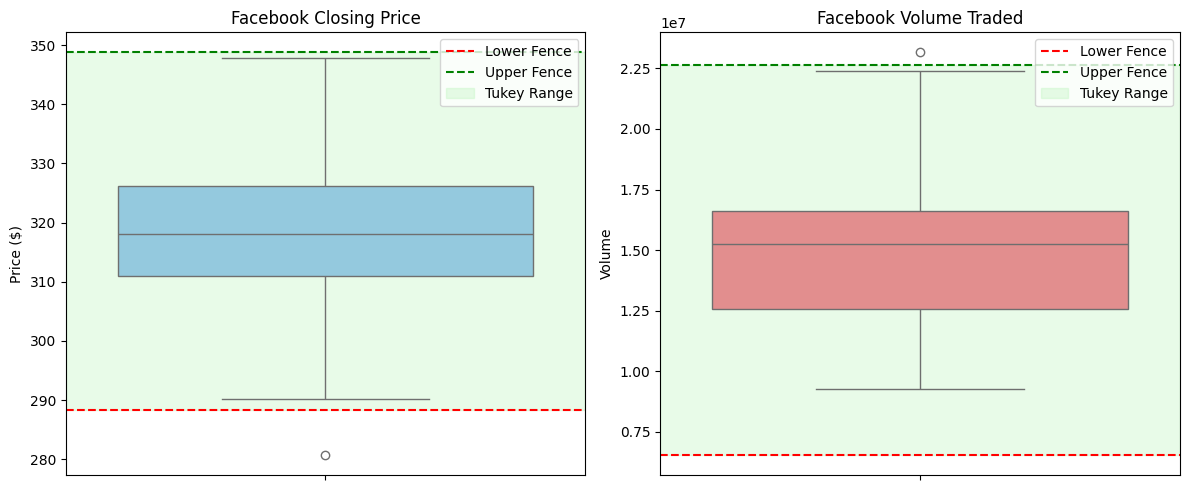

In [15]:

# Sample data (replace with your real Facebook stock data)
np.random.seed(42)
df = pd.DataFrame({
    'Close': np.random.normal(320, 15, 100),
    'Volume': np.random.normal(1.5e7, 3e6, 100)
})

# Calculate Q1, Q3, and IQR for both
def tukey_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

lower_close, upper_close = tukey_bounds(df['Close'])
lower_vol, upper_vol = tukey_bounds(df['Volume'])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Boxplot for Close price ---
sns.boxplot(y=df['Close'], ax=axes[0], color='skyblue')
axes[0].axhline(lower_close, color='red', linestyle='--', label='Lower Fence')
axes[0].axhline(upper_close, color='green', linestyle='--', label='Upper Fence')
axes[0].axhspan(lower_close, upper_close, color='lightgreen', alpha=0.2, label='Tukey Range')
axes[0].set_title('Facebook Closing Price')
axes[0].set_ylabel('Price ($)')
axes[0].legend()

# --- Boxplot for Volume traded ---
sns.boxplot(y=df['Volume'], ax=axes[1], color='lightcoral')
axes[1].axhline(lower_vol, color='red', linestyle='--', label='Lower Fence')
axes[1].axhline(upper_vol, color='green', linestyle='--', label='Upper Fence')
axes[1].axhspan(lower_vol, upper_vol, color='lightgreen', alpha=0.2, label='Tukey Range')
axes[1].set_title('Facebook Volume Traded')
axes[1].set_ylabel('Volume')
axes[1].legend()

plt.tight_layout()
plt.show()


In [23]:
print(df.columns)


Index(['Close', 'Volume'], dtype='object')


In [24]:
print(df.index)


RangeIndex(start=0, stop=100, step=1)


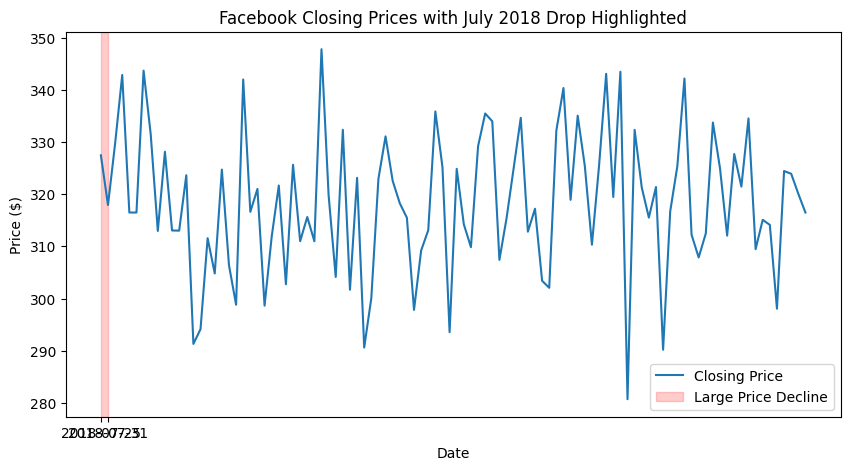

In [25]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df.index, df['Close'], label='Closing Price')

# Shade the decline period
ax.axvspan('2018-07-25', '2018-07-31', color='red', alpha=0.2, label='Large Price Decline')

ax.set_title('Facebook Closing Prices with July 2018 Drop Highlighted')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.show()


In [27]:
print(df.columns)


Index(['Close', 'Volume'], dtype='object')


In [28]:
import pandas as pd

# Suppose the data starts on 2018-07-01 and has daily frequency
df['Date'] = pd.date_range(start='2018-07-01', periods=len(df), freq='D')


In [31]:
df['Date'] = pd.date_range(start='2018-03-01', periods=len(df), freq='D')


In [32]:
print(df['Date'].min(), df['Date'].max())


2018-03-01 00:00:00 2018-06-08 00:00:00


In [33]:
event1_date = pd.to_datetime('2018-07-25')
event1_price = df.iloc[(df['Date'] - event1_date).abs().argsort()[0]]['Close']


NameError: name 'ev' is not defined

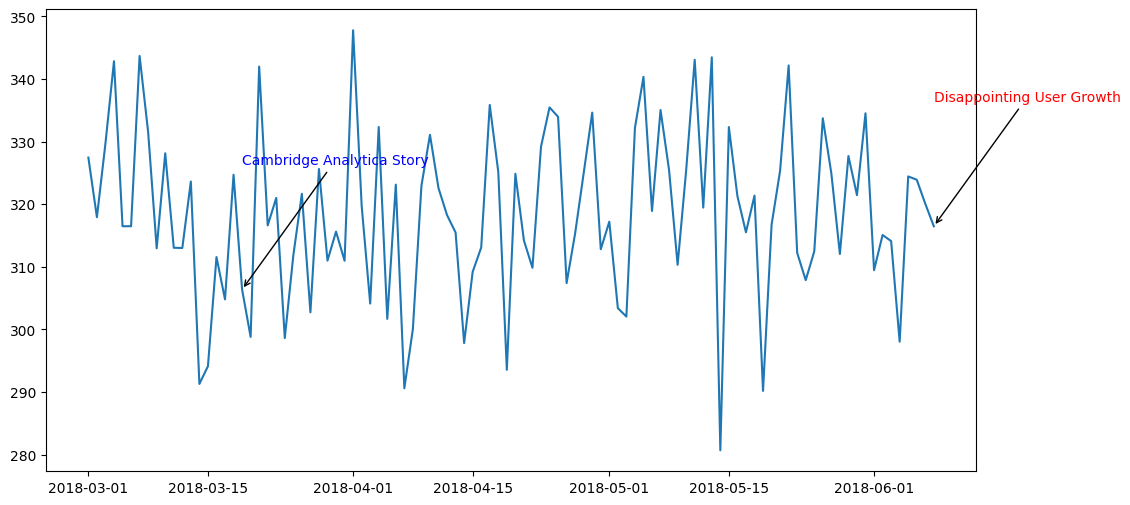

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: create a Date column if your data is daily
# Adjust start date and frequency to match your actual dataset
df['Date'] = pd.date_range(start='2018-03-01', periods=len(df), freq='D')

fig, ax = plt.subplots(figsize=(12,6))

# Plot closing price
ax.plot(df['Date'], df['Close'], label='Closing Price')

# Function to get closest date's closing price
def get_closest_price(df, target_date):
    target_date = pd.to_datetime(target_date)
    closest_idx = (df['Date'] - target_date).abs().argsort()[0]
    return df.iloc[closest_idx]['Date'], df.iloc[closest_idx]['Close']

# --- Event 1 ---
event1_date, event1_price = get_closest_price(df, '2018-07-25')
ax.annotate(
    'Disappointing User Growth',
    xy=(event1_date, event1_price),
    xytext=(event1_date, event1_price + 20),
    arrowprops=dict(facecolor='red', arrowstyle='->'),
    fontsize=10,
    color='red'
)

# --- Event 2 ---
event2_date, event2_price = get_closest_price(df, '2018-03-19')
ax.annotate(
    'Cambridge Analytica Story',
    xy=(event2_date, event2_price),
    xytext=(event2_date, event2_price + 20),
    arrowprops=dict(facecolor='blue', arrowstyle='->'),
    fontsize=10,
    color='blue'
)

# --- Event 3 ---
ev


/tmp/ipython-input-4043715524.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap, len(df_list))


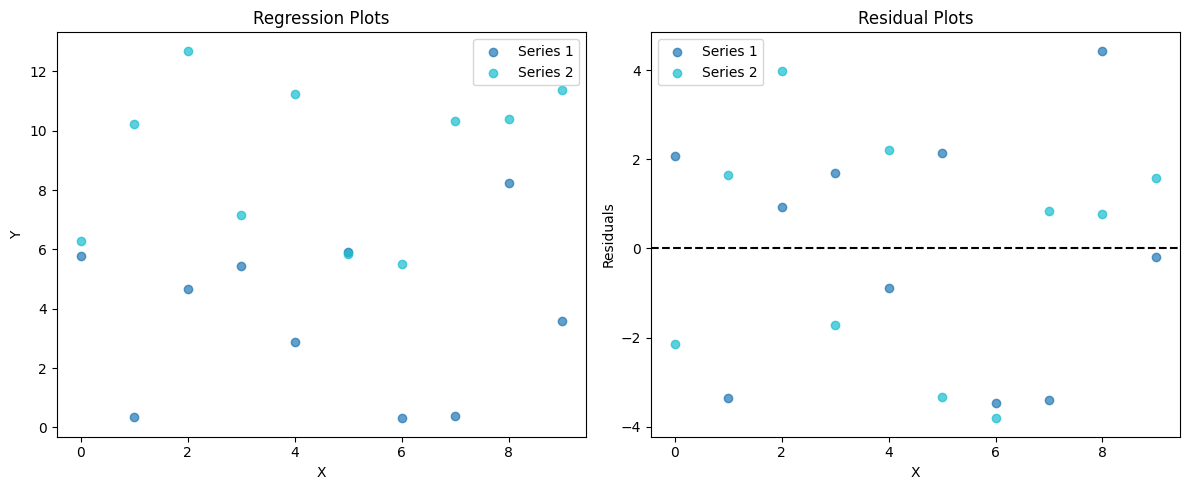

In [41]:
df1 = pd.DataFrame({'X': np.arange(10), 'Y': np.random.rand(10)*10})
df2 = pd.DataFrame({'X': np.arange(10), 'Y': np.random.rand(10)*10 + 5})

# Call the function
reg_resid_plots([df1, df2], x_col='X', y_col='Y')
